# HCI Car Simulation_Data Analysis

In [75]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import re
import pandas as pd
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt


In [145]:
%config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

# 0. Load data and write data dictionary

In [76]:
phase = "phaseI"
sub_nums = np.arange(1,13,1)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir = DATA_DIR / phase

df_phase = pd.read_csv(data_dir / "PhaseI_Block.csv")
df_pattern = pd.read_csv(data_dir / "RecommendationPatterns.csv")

In [247]:
data_dict = defaultdict(dict)

for sub in sub_nums:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 3, f"sub{sub} has more than 3 folders"

    for j, sub_dir in enumerate(sub_dirs):
        block = j + 4 if sub % 2 == 0 else j + 1
        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        scene_key = f"scene_{row['SceneID']}"

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        data_dict[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

In [78]:
def build_trial_level_df(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")

            df["accept_bin"] = (df["reaction"] == "accept").astype(int)

            for _, row in df.iterrows():
                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(row["type"]),
                    "accept": row["accept_bin"]
                })

    return pd.DataFrame(records)

df_trial = build_trial_level_df(data_dict)

# 1. Mixed Effect Modeling
## 1.1 LMM treat sub as random intercept

In [79]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"]
)

result = model.fit()
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          358              Method:                      REML     
No. Groups:                12               Scale:                       0.1946   
Min. group size:           28               Log-Likelihood:              -232.3901
Max. group size:           30               Converged:                   Yes      
Mean group size:           29.8                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.200    0.184  6.519 0.000  0.839  1.561
driving[T.manual]                       -0.233    0.260 -0.896 0.370 -0.744  0.277
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 1.1 Treat Type Independently

In [106]:
for t in [1, 2]:
    df_sub = df_trial[df_trial["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ driving * scene",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())


=== Type 1 ===
                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        accept  
No. Observations:          179            Method:                    REML    
No. Groups:                12             Scale:                     0.1630  
Min. group size:           14             Log-Likelihood:            -98.9089
Max. group size:           15             Converged:                 No      
Mean group size:           14.9                                              
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.900    0.074 12.147 0.000  0.755  1.045
driving[T.manual]                  -0.067    0.105 -0.636 0.525 -0.272  0.139
scene[T.scene_2]                   -0.072    0.105 -0.688 0.491 -0.2

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

## 1.2 LMM treat sub as random slope

In [81]:
model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"],
    re_formula="~type"
)

result = model.fit()
print(result.summary())

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          358              Method:                      REML     
No. Groups:                12               Scale:                       0.1844   
Min. group size:           28               Log-Likelihood:              -244.1729
Max. group size:           30               Converged:                   No       
Mean group size:           29.8                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.200    0.198  6.063 0.000  0.812  1.588
driving[T.manual]                       -0.233    0.280 -0.834 0.404 -0.782  0.315
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2218:

# 2. Acceptance rate description

In [82]:
def extract_reaction_stats(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")
            df["pattern"] = df["current_encode_id"].astype(str)
            df["type_sub"] = df["pattern"].str[1:3]

            for t in ["1", "2"]:
                sub_df = df[df["type"] == t]
                if len(sub_df) == 0:
                    continue

                total = len(sub_df)
                counts = sub_df["reaction"].value_counts()

                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "driving": driving,
                    "type": int(t),
                    "accept": counts.get("accept", 0)/total,
                    "reject": counts.get("reject", 0)/total,
                    "ignore": counts.get("ignore", 0)/total,
                })

    return pd.DataFrame(records)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

type_palette = {
    1: "#1D9CFF",
    2: "#FFA51C",
}

driving_mode_palette = {
    'auto': "#651DFF",
    'manual': "#FFA51C",
}

def plot_scene_box(df):
    for metric in ["accept", "reject", "ignore"]:
        for t in [1, 2]:
            plt.figure(figsize=(8,5))
            sns.boxplot(
                data=df[df["type"]==t],
                x="scene",
                y=metric,
                hue="driving"
            )
            plt.title(f"{metric} (Type {t}) across scenes")
            plt.xticks(rotation=30)
            plt.show()

def plot_scene_facet(df):
    for metric in ["accept", "reject", "ignore"]:
        g = sns.catplot(
            data=df,
            x="scene",
            y=metric,
            hue="driving",
            col="type",
            kind="box",
            height=4,
            aspect=1.2
        )
        g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=30)
        plt.show()

def plot_type_facet(df):
    for metric in ["accept"]:
        g = sns.catplot(
            data=df,
            x="type",
            y=metric,
            hue="type",
            palette=type_palette,
            col="scene",
            kind="bar",
            errorbar="se",
            height=3,
            aspect=0.5,
            legend=False,
        )
        
        # g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        g.set_xticklabels(["type 1", "type 2"])
        g.set_axis_labels("", f"{metric} ratio")

        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=0)
            ax.set_ylim(0, 1)
            ax.set_yticks(np.linspace(0, 1, 6))
        
        plt.show()

In [96]:
from scipy.stats import mannwhitneyu, wilcoxon

def summarize_scene(df):
    summary = df.groupby(["scene","driving","type"]).agg(
        accept_mean=("accept","mean"),
        reject_mean=("reject","mean"),
        ignore_mean=("ignore","mean"),
        n=("sub","count")
    ).reset_index()

    print(summary)
    return summary

from scipy.stats import mannwhitneyu

def test_driving_per_scene(df):
    print("\n=== Driving effect per scene ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for scene in df["scene"].unique():
            for t in [1,2]:
                sub_df = df[(df["scene"]==scene) & (df["type"]==t)]

                g1 = sub_df[sub_df["driving"]=="manual"][metric]
                g2 = sub_df[sub_df["driving"]=="auto"][metric]

                if len(g1)>0 and len(g2)>0:
                    _, p = mannwhitneyu(g1, g2)
                    print(f"{scene}, type{t}: p={p:.4f}")

from scipy.stats import friedmanchisquare

def test_scene_effect(df):
    print("\n=== Scene effect ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index="sub",
                columns="scene",
                values=metric
            ).dropna()

            if pivot.shape[1] >= 3:
                stat, p = friedmanchisquare(*[pivot[c] for c in pivot.columns])
                print(f"type{t}: p={p:.4f}")

def test_interaction_proxy(df):
    print("\n=== Interaction proxy (Δscene effect between driving) ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index=["sub","driving"],
                columns="scene",
                values=metric
            ).dropna()

            pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)

            manual = pivot[pivot.index.get_level_values("driving")=="manual"]["range"]
            auto   = pivot[pivot.index.get_level_values("driving")=="auto"]["range"]

            if len(manual)>0 and len(auto)>0:
                _, p = mannwhitneyu(manual, auto)
                print(f"type{t}: p={p:.4f}")

from scipy.stats import mannwhitneyu

def test_scene_type_diff(df):
    print("\n=== Type1 vs Type2 difference within each scene ===")

    for metric in ["accept", "reject", "ignore"]:
        print(f"\n--- {metric} ---")

        for scene in sorted(df["scene"].unique()):
            scene_df = df[df["scene"] == scene]

            type1 = scene_df.loc[scene_df["type"] == 1, metric].dropna()
            type2 = scene_df.loc[scene_df["type"] == 2, metric].dropna()

            if len(type1) > 0 and len(type2) > 0:
                stat, p = mannwhitneyu(type1, type2, alternative="two-sided")
                print(
                    f"{scene}: "
                    f"type1(n={len(type1)}, mean={type1.mean():.3f}, median={type1.median():.3f}) | "
                    f"type2(n={len(type2)}, mean={type2.mean():.3f}, median={type2.median():.3f}) | "
                    f"U={stat:.3f}, p={p:.4f}"
                )
            else:
                print(f"{scene}: insufficient data")

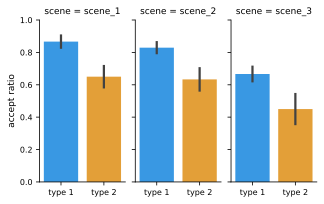

      scene driving  type  accept_mean  reject_mean  ignore_mean  n
0   scene_1    auto     1     0.900000     0.033333     0.066667  6
1   scene_1    auto     2     0.600000     0.366667     0.033333  6
2   scene_1  manual     1     0.833333     0.066667     0.100000  6
3   scene_1  manual     2     0.700000     0.166667     0.133333  6
4   scene_2    auto     1     0.825000     0.075000     0.100000  6
5   scene_2    auto     2     0.566667     0.400000     0.033333  6
6   scene_2  manual     1     0.833333     0.133333     0.033333  6
7   scene_2  manual     2     0.700000     0.200000     0.100000  6
8   scene_3    auto     1     0.733333     0.200000     0.066667  6
9   scene_3    auto     2     0.400000     0.566667     0.033333  6
10  scene_3  manual     1     0.600000     0.200000     0.200000  6
11  scene_3  manual     2     0.500000     0.333333     0.166667  6

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_1: type1(n=12, mean=0.867, median=0.800) 

In [150]:
df_stats = extract_reaction_stats(data_dict)

# plot_scene_facet(df_stats)
plot_type_facet(df_stats)

summary = summarize_scene(df_stats)

# test_driving_per_scene(df_stats)
# test_scene_effect(df_stats)
# test_interaction_proxy(df_stats)
test_scene_type_diff(df_stats)

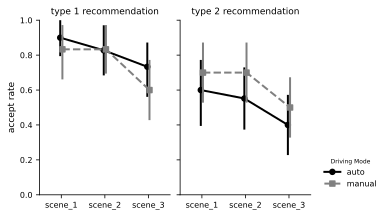

In [167]:
df_trial["driving"] = df_trial["driving"].astype("category")
df_trial["scene"] = df_trial["scene"].astype("category")
df_trial["type"] = df_trial["type"].astype("category")

# plt.figure(figsize=(3,3))

g = sns.catplot(
    data=df_trial,
    x="scene",
    y="accept",
    hue="driving",
    col="type",
    kind="point",
    dodge=True,
    errorbar=('ci', 95),
    height=3,
    aspect=0.6,
    palette=["black", "gray"],
    markers=["o", "s"],
    linestyles=["-", "--"],
    linewidth = 2.0,
)

g.set_axis_labels("", "accept rate")
g.set_titles("type {col_name} recommendation")
g._legend.set_bbox_to_anchor((1.0, 0.1))
g._legend.set_loc("lower left")
g._legend.set_title("Driving Mode")
# g.fig.suptitle(
#     "Accept Rate by Scene, Driving Mode, and Type",
#     y=1.0,
#     ha='center'
# )

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))

plt.tight_layout()
plt.show()

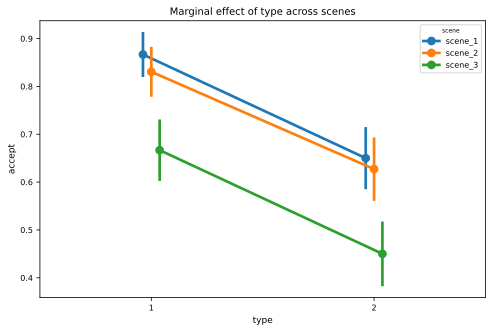

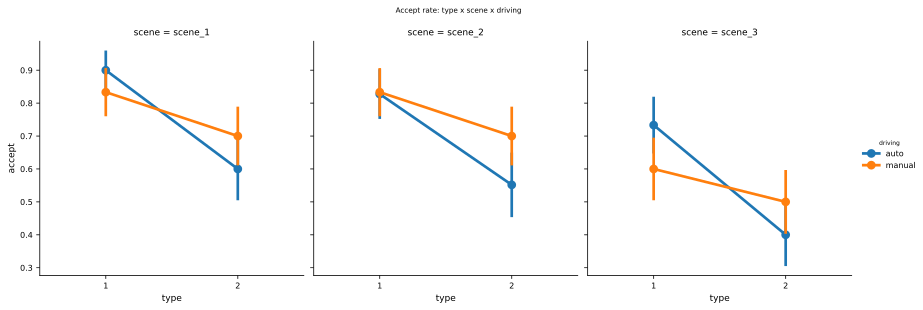

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1811/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1811/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1811/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain

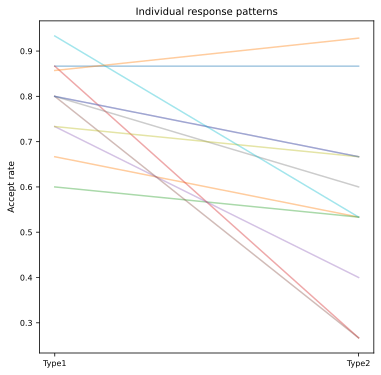

In [166]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="scene",
    dodge=True,
    errorbar="se"
)

plt.title("Marginal effect of type across scenes")
plt.show()

g = sns.catplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="driving",
    col="scene",
    kind="point",
    errorbar="se",
    height=4,
    aspect=1,
)

g.fig.suptitle("Accept rate: type x scene x driving", y=1.05)
plt.show()

plt.figure(figsize=(6,6))

for sub in df_trial["sub"].unique():
    sub_df = df_trial[df_trial["sub"]==sub]
    pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")

    plt.plot([1,2], pivot.values.flatten(), alpha=0.4)

plt.xticks([1,2], ["Type1", "Type2"])
plt.ylabel("Accept rate")
plt.title("Individual response patterns")
plt.show()

## 3. Subject clustering

In [88]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot.columns = ["accept_type1", "accept_type2"]
pivot["diff"] = pivot["accept_type1"] - pivot["accept_type2"]

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1811/1223868461.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


In [89]:
from sklearn.cluster import KMeans

X = pivot[["accept_type1", "accept_type2"]].values

kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
pivot["cluster"] = kmeans.labels_

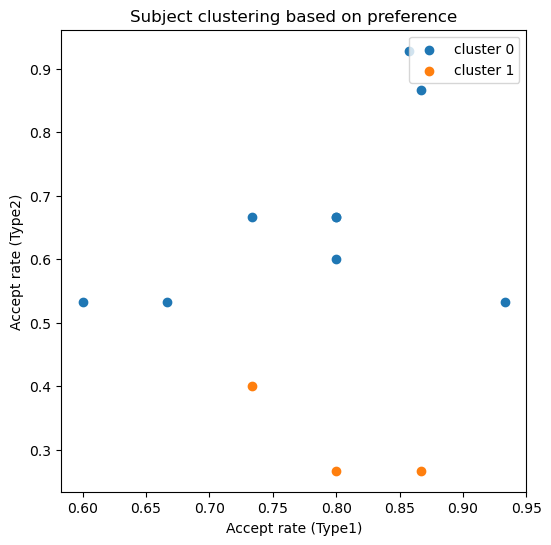

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for c in pivot["cluster"].unique():
    sub_df = pivot[pivot["cluster"]==c]
    plt.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )

plt.xlabel("Accept rate (Type1)")
plt.ylabel("Accept rate (Type2)")
plt.legend()
plt.title("Subject clustering based on preference")
plt.show()

In [91]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot["diff"] = pivot[1] - pivot[2]
print(pivot)

type         1         2      diff
sub                               
1     0.866667  0.866667  0.000000
2     0.666667  0.533333  0.133333
3     0.600000  0.533333  0.066667
4     0.866667  0.266667  0.600000
5     0.733333  0.400000  0.333333
6     0.800000  0.266667  0.533333
7     0.800000  0.666667  0.133333
8     0.800000  0.600000  0.200000
9     0.733333  0.666667  0.066667
10    0.933333  0.533333  0.400000
11    0.800000  0.666667  0.133333
12    0.857143  0.928571 -0.071429


/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_1811/1211643864.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


# 4. Per-reaction modeling
for each reaction, we will aggregate:
meta:
    sub_id: int,
    scene_id: int,
    mode: int,
    recommendation: int(5 digits),
    recommendation category: int (1 digits),
    recommendation subcategory: int (3 digits),
prior:
    subject prior probablity of acceptance of the recommendation subcategory: float, 
    mean steering input: float,
    var steering input: float,
    mean tottle input: float,
    var tottle input: float,
scenario:
    intensity of the recommendation: float,
    coherence of the recommendation: float,
    mean stiring input zscore -2s: float,
    mean tottle input zscore -2s: float,
reaction:
    accept: bool,
    reaction_time: ms,
    mean stiring input zscore +5s: float,
    mean tottle input zscore +5s: float,
evaluation:
    disturance: float,
    satisfaction: float,
    appropriateness: float,

and build a dynamic model to take in the prior, scenario variables to model acceptance. We can assuame that the biological time constant for accept and reject are the same across participants.


In [249]:
import numpy as np
import pandas as pd
from collections import defaultdict


def _safe_mean(x):
    if len(x) == 0:
        return np.nan
    return float(np.mean(x))


def _safe_var(x):
    if len(x) == 0:
        return np.nan
    return float(np.var(x, ddof=0))


def _zscore_with_ref(x, ref_mean, ref_std):
    if pd.isna(ref_std) or ref_std == 0:
        return np.full(len(x), np.nan)
    return (x - ref_mean) / ref_std


def _find_time_col(df):
    """
    Try to find the best timestamp column in PawnCar.csv.
    Prefer _time_ms, otherwise fallback to gametime_ms.
    """
    if "_time_ms" in df.columns:
        # print("Using _time_ms as time column for PawnCar.csv")
        return "_time_ms"
    elif "gametime_ms" in df.columns:
        return "gametime_ms"
    else:
        raise ValueError("PawnCar.csv must contain either '_time_ms' or 'gametime_ms'.")


def _extract_pattern_info(pattern_id):
    """
    pattern_id / current_encode_id assumed to be 5-digit int-like.
    Returns:
        recommendation: int
        category: int (1 digit)
        subcategory: int (3 digits; here use last 3 digits)
    """
    s = str(int(pattern_id)).zfill(5)
    recommendation = int(s)
    category = int(s[0])
    subcategory = int(s[:3])
    return recommendation, category, subcategory


def _get_window_slice(df_car, time_col, center_t, start_offset_ms, end_offset_ms):
    """
    Window: [center_t + start_offset_ms, center_t + end_offset_ms]
    """
    print(f"Finding window slice in df_car with {len(df_car)} rows, time_col={time_col}")
    print("df_car time range: ", df_car[time_col].min(), " to ", df_car[time_col].max())
    t0 = center_t + start_offset_ms
    t1 = center_t + end_offset_ms
    print(f"Getting window slice: center={center_t} ms, start_offset={t0} ms, end_offset={t1} ms")
    return df_car[(df_car[time_col] >= t0) & (df_car[time_col] <= t1)].copy()


def build_per_reaction_df(
    data_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
    default_prior_accept_prob=0.5,
    default_eval_value=np.nan,
):
    """
    Build per-reaction dataframe from nested data_dict.

    Required:
    - trial["marker"] contains:
        _time_ms, gametime_ms, scene_id, block_id, trial_id, current_encode_id, marker
    - trial["car"] contains:
        throttle_input, steering_input, and timestamp column
          (_time_ms preferred, otherwise gametime_ms)

    Returns:
        pd.DataFrame, one row per reaction event
    """
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        mode = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df_marker = trial["marker"].copy()
            df_car = trial["car"].copy()

            if len(df_marker) == 0 or len(df_car) == 0:
                continue

            # ---------- basic checks ----------
            required_marker_cols = {
                "_time_ms", "gametime_ms",
                "trial_id", "current_encode_id", "marker"
            }
            missing_marker = required_marker_cols - set(df_marker.columns)
            if missing_marker:
                raise ValueError(
                    f"{sub_key}-{scene_key}: marker is missing columns {missing_marker}"
                )

            # required_car_cols = {"steering_input", "throttle_input"}
            required_car_cols = {"throttle_input",}
            missing_car = required_car_cols - set(df_car.columns)
            if missing_car:
                raise ValueError(
                    f"{sub_key}-{scene_key}: car is missing columns {missing_car}"
                )

            car_time_col = _find_time_col(df_car)

            # sort by time
            df_marker = df_marker.sort_values("_time_ms")
            df_car = df_car.sort_values("_time_ms")
            print(df_car[[car_time_col]].describe())

            # ---------- prior over whole subject-scene-mode ----------
            # steering_mean_all = df_car["steering_input"].mean()
            # steering_std_all = df_car["steering_input"].std(ddof=0)
            # steering_var_all = df_car["steering_input"].var(ddof=0)

            throttle_mean_all = df_car["throttle_input"].mean()
            throttle_std_all = df_car["throttle_input"].std(ddof=0)
            throttle_var_all = df_car["throttle_input"].var(ddof=0)

            # ---------- reaction rows ----------
            df_react = df_marker[df_marker["marker"].str.startswith("reaction_")].copy()
            if len(df_react) == 0:
                continue

            for idx, react_row in df_react.iterrows():
                reaction_marker = react_row["marker"]               # e.g. reaction_accept
                reaction_label = reaction_marker.replace("reaction_", "")
                accept_bool = (reaction_label == "accept")

                reaction_time_unix = react_row["_time_ms"]
                reaction_time_game = react_row["gametime_ms"]
                trial_id = react_row["trial_id"]
                pattern_id = react_row["current_encode_id"]

                recommendation, rec_category, rec_subcategory = _extract_pattern_info(pattern_id)

                # ---------- find matched trigger ----------
                # same trial + same encode + before this reaction
                trigger_candidates = df_marker[
                    (df_marker["trial_id"] == trial_id) &
                    (df_marker["current_encode_id"] == pattern_id) &
                    (df_marker["marker"] == "trigger") &
                    (df_marker["_time_ms"] <= reaction_time_unix)
                ].copy()

                if len(trigger_candidates) == 0:
                    # fallback: same trial only
                    trigger_candidates = df_marker[
                        (df_marker["trial_id"] == trial_id) &
                        (df_marker["marker"] == "trigger") &
                        (df_marker["_time_ms"] <= reaction_time_unix)
                    ].copy()

                if len(trigger_candidates) == 0:
                    trigger_time_unix = np.nan
                    reaction_time_ms = np.nan
                else:
                    trigger_row = trigger_candidates.sort_values("_time_ms").iloc[-1]
                    trigger_time_unix = trigger_row["_time_ms"]
                    reaction_time_ms = reaction_time_unix - trigger_time_unix
                    print(f"{sub_key}-{scene_key}-trial{trial_id}: found trigger for reaction at {trigger_time_unix} ms")

                # ---------- windows around reaction ----------
                df_pre = _get_window_slice(
                    df_car, car_time_col,
                    center_t=trigger_time_unix if car_time_col == "_time_ms" else reaction_time_game,
                    start_offset_ms=-pre_window_ms,
                    end_offset_ms=0
                )

                df_post = _get_window_slice(
                    df_car, car_time_col,
                    center_t=trigger_time_unix if car_time_col == "_time_ms" else reaction_time_game,
                    start_offset_ms=0,
                    end_offset_ms=post_window_ms
                )

                # ---------- scenario window zscores ----------
                if len(df_pre) > 0:
                    # pre_steer_z = _zscore_with_ref(
                    #     df_pre["steering_input"].to_numpy(),
                    #     steering_mean_all,
                    #     steering_std_all
                    # )
                    pre_throttle_z = _zscore_with_ref(
                        df_pre["throttle_input"].to_numpy(),
                        throttle_mean_all,
                        throttle_std_all
                    )
                    # mean_steering_z_pre2s = _safe_mean(pre_steer_z)
                    mean_throttle_z_pre2s = _safe_mean(pre_throttle_z)
                    mean_throttle_pre2s = df_pre["throttle_input"].mean()
                else:
                    # mean_steering_z_pre2s = np.nan
                    mean_throttle_z_pre2s = np.nan
                    print(f"{sub_key}-{scene_key}-trial{trial_id}: no data in pre-reaction window")
                    # mean_throttle_pre2s = np.nan

                # ---------- reaction window zscores ----------
                if len(df_post) > 0:
                    # post_steer_z = _zscore_with_ref(
                    #     df_post["steering_input"].to_numpy(),
                    #     steering_mean_all,
                    #     steering_std_all
                    # )
                    post_throttle_z = _zscore_with_ref(
                        df_post["throttle_input"].to_numpy(),
                        throttle_mean_all,
                        throttle_std_all
                    )
                    # mean_steering_z_post5s = _safe_mean(post_steer_z)
                    mean_throttle_z_post5s = _safe_mean(post_throttle_z)
                    mean_throttle_post5s = df_post["throttle_input"].mean()
                else:
                    # mean_steering_z_post5s = np.nan
                    mean_throttle_z_post5s = np.nan
                    mean_throttle_post5s = np.nan

                # ---------- pattern-level scenario features ----------
                # default NaN first
                intensity = 0.5
                coherence = 0

                df_pattern = trial.get("pattern", None)
                if df_pattern is not None and len(df_pattern) > 0:
                    if "intensity" in df_pattern.columns:
                        intensity = df_pattern["intensity"].iloc[0]
                    elif "Intensity" in df_pattern.columns:
                        intensity = df_pattern["Intensity"].iloc[0]

                    if "coherence" in df_pattern.columns:
                        coherence = df_pattern["coherence"].iloc[0]
                    elif "Coherence" in df_pattern.columns:
                        coherence = df_pattern["Coherence"].iloc[0]
                
                car_density_map = {
                    1: 0.2,
                    2: 0.8,
                    3: 0.8,
                    4: 0.2,
                    5: 0.8,
                    6: 0.8,
                }

                time_pressure_map = {
                    1: 0,
                    2: 0,
                    3: 1,
                    4: 0,
                    5: 0,
                    6: 1,
                }

                records.append({
                    # ---------------- meta ----------------
                    "sub_id": sub,
                    "scene_id": scene_key,
                    "mode": mode,
                    "trial_id": trial_id,
                    "recommendation": recommendation,
                    "recommendation_category": rec_category,
                    "recommendation_subcategory": rec_subcategory,

                    # ---------------- prior ----------------
                    "subject_prior_accept_prob_subcategory": default_prior_accept_prob,
                    # "prior_mean_steering_input": float(steering_mean_all),
                    # "prior_var_steering_input": float(steering_var_all),
                    "prior_mean_throttle_input": float(throttle_mean_all),
                    "prior_var_throttle_input": float(throttle_var_all),

                    # ---------------- scenario ----------------
                    "intensity": intensity,
                    "coherence": coherence,
                    # "mean_steering_input_zscore_pre2s": mean_steering_z_pre2s,
                    "mean_throttle_input_zscore_pre2s": mean_throttle_z_pre2s,
                    "mean_throttle_pre2s": mean_throttle_pre2s,
                    "car_density": car_density_map[int(scene_key.split("_")[1])],
                    "time_pressure": time_pressure_map[int(scene_key.split("_")[1])],

                    # ---------------- reaction ----------------
                    "reaction": reaction_label,
                    "accept": bool(accept_bool),
                    "reaction_time_ms": reaction_time_ms,
                    # "mean_steering_input_zscore_post5s": mean_steering_z_post5s,
                    "mean_throttle_input_zscore_post5s": mean_throttle_z_post5s,
                    "mean_throttle_post5s": mean_throttle_post5s,

                    # ---------------- evaluation ----------------
                    "disturbance": default_eval_value,
                    "satisfaction": default_eval_value,
                    "appropriateness": default_eval_value,

                    # ---------------- bookkeeping ----------------
                    "reaction__time_ms": reaction_time_unix,
                    "trigger__time_ms": trigger_time_unix,
                })

    return pd.DataFrame(records)

In [207]:
def build_per_reaction_data_dict(df_reaction):
    """
    Nested dict:
    data[sub_id][scene_id] = list of reaction dicts
    """
    out = defaultdict(lambda: defaultdict(list))

    for _, row in df_reaction.iterrows():
        sub_key = f"sub_{int(row['sub_id'])}"
        scene_key = str(row["scene_id"])

        item = {
            "meta": {
                "sub_id": int(row["sub_id"]),
                "scene_id": row["scene_id"],
                "mode": row["mode"],
                "trial_id": int(row["trial_id"]) if not pd.isna(row["trial_id"]) else None,
                "recommendation": int(row["recommendation"]),
                "recommendation_category": int(row["recommendation_category"]),
                "recommendation_subcategory": int(row["recommendation_subcategory"]),
            },
            "prior": {
                "subject_prior_accept_prob_subcategory": float(row["subject_prior_accept_prob_subcategory"]),
                # "mean_steering_input": float(row["prior_mean_steering_input"]) if not pd.isna(row["prior_mean_steering_input"]) else np.nan,
                # "var_steering_input": float(row["prior_var_steering_input"]) if not pd.isna(row["prior_var_steering_input"]) else np.nan,
                "mean_throttle_input": float(row["prior_mean_throttle_input"]) if not pd.isna(row["prior_mean_throttle_input"]) else np.nan,
                "var_throttle_input": float(row["prior_var_throttle_input"]) if not pd.isna(row["prior_var_throttle_input"]) else np.nan,
            },
            "scenario": {
                "intensity": float(row["intensity"]) if not pd.isna(row["intensity"]) else np.nan,
                "coherence": float(row["coherence"]) if not pd.isna(row["coherence"]) else np.nan,
                # "mean_steering_input_zscore_pre2s": float(row["mean_steering_input_zscore_pre2s"]) if not pd.isna(row["mean_steering_input_zscore_pre2s"]) else np.nan,
                "mean_throttle_input_zscore_pre2s": float(row["mean_throttle_input_zscore_pre2s"]) if not pd.isna(row["mean_throttle_input_zscore_pre2s"]) else np.nan,
            },
            "reaction": {
                "reaction": row["reaction"],
                "accept": bool(row["accept"]),
                "reaction_time_ms": float(row["reaction_time_ms"]) if not pd.isna(row["reaction_time_ms"]) else np.nan,
                # "mean_steering_input_zscore_post5s": float(row["mean_steering_input_zscore_post5s"]) if not pd.isna(row["mean_steering_input_zscore_post5s"]) else np.nan,
                "mean_throttle_input_zscore_post5s": float(row["mean_throttle_input_zscore_post5s"]) if not pd.isna(row["mean_throttle_input_zscore_post5s"]) else np.nan,
            },
            "evaluation": {
                "disturbance": float(row["disturbance"]) if not pd.isna(row["disturbance"]) else np.nan,
                "satisfaction": float(row["satisfaction"]) if not pd.isna(row["satisfaction"]) else np.nan,
                "appropriateness": float(row["appropriateness"]) if not pd.isna(row["appropriateness"]) else np.nan,
            }
        }

        out[sub_key][scene_key].append(item)

    return out

In [250]:
df_reaction = build_per_reaction_df(
    data_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
)

print(df_reaction.head())

reaction_data_dict = build_per_reaction_data_dict(df_reaction)

           _time_ms
count  3.541500e+04
mean   1.773519e+12
std    2.882451e+05
min    1.773518e+12
25%    1.773519e+12
50%    1.773519e+12
75%    1.773519e+12
max    1.773519e+12
sub_1-scene_1-trial1: found trigger for reaction at 1773518317579 ms
Finding window slice in df_car with 35415 rows, time_col=_time_ms
df_car time range:  1773518251729  to  1773519242658
Getting window slice: center=1773518317579 ms, start_offset=1773518315579 ms, end_offset=1773518317579 ms
Finding window slice in df_car with 35415 rows, time_col=_time_ms
df_car time range:  1773518251729  to  1773519242658
Getting window slice: center=1773518317579 ms, start_offset=1773518317579 ms, end_offset=1773518322579 ms
sub_1-scene_1-trial2: found trigger for reaction at 1773518454738 ms
Finding window slice in df_car with 35415 rows, time_col=_time_ms
df_car time range:  1773518251729  to  1773519242658
Getting window slice: center=1773518454738 ms, start_offset=1773518452738 ms, end_offset=1773518454738 ms
Finding

## 3.1 1d Dynamics Simulation

In [254]:
# =========================
# 1. Basic utility functions
# =========================

def safe_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# =========================
# 2. Input drive u
# =========================
# u = beta_c * coherence + beta_i * intensity + beta_ci * coherence * intensity - gamma * pressure
# Here pressure = mean_throttle_input_zscore_pre2s

def compute_drive_u(coherence, intensity, pressure,
                    beta_c=1.2, beta_i=0.8, beta_ci=0.5, gamma=1.0):
    u = (
        beta_c * coherence
        + beta_i * intensity
        + beta_ci * coherence * intensity
        - gamma * pressure
    )
    return u


# =========================
# 3. Initial state from prior
# =========================

def compute_x0_from_prior(prior_accept_prob, kappa=1.0):
    return kappa * safe_logit(prior_accept_prob)


# =========================
# 4. 1D dynamical system
# =========================
# dx/dt = -lam * x + u + noise
# Euler simulation

def simulate_decision_1d(
    x0,
    u,
    lam=1.0,
    sigma=0.0,
    dt=0.01,
    T=3.0,
    theta=0.0,
    random_state=None
):
    rng = np.random.default_rng(random_state)

    n_steps = int(T / dt) + 1
    t = np.linspace(0, T, n_steps)

    x = np.zeros(n_steps)
    x[0] = x0

    for k in range(n_steps - 1):
        noise = sigma * np.sqrt(dt) * rng.normal()
        dx = (-lam * x[k] + u) * dt + noise
        x[k + 1] = x[k] + dx

    x_final = x[-1]
    p_accept = sigmoid(x_final - theta)
    accept = int(p_accept >= 0.5)

    return {
        "t": t,
        "x": x,
        "x_final": x_final,
        "p_accept": p_accept,
        "accept": accept,
        "nullcline_x": u / lam
    }


# =========================
# 5. Plot phase line / nullcline
# =========================
# For 1D system, the "nullcline" is the equilibrium x* = u / lam
# We can plot dx/dt as a function of x and mark where dx/dt = 0

def plot_phase_line_and_nullcline(
    u,
    lam=1.0,
    x_min=-5,
    x_max=5,
    n=400,
    ax=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    x_grid = np.linspace(x_min, x_max, n)
    dxdt = -lam * x_grid + u
    x_star = u / lam

    ax.plot(x_grid, dxdt, label=r'$\dot{x}=-\lambda x + u$')
    ax.axhline(0, linestyle='--')
    ax.axvline(x_star, linestyle='--', label=fr'nullcline $x^*={x_star:.2f}$')

    ax.set_xlabel("x")
    ax.set_ylabel("dx/dt")
    ax.set_title("1D Phase Line / Nullcline")
    ax.legend()
    return ax


# =========================
# 6. Plot trajectories from different initial states
# =========================

def plot_trajectories_different_x0(
    x0_list,
    u,
    lam=1.0,
    sigma=0.0,
    dt=0.01,
    T=3.0,
    theta=0.0
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: phase line with nullcline
    plot_phase_line_and_nullcline(u=u, lam=lam, ax=axes[0])

    # Mark initial points on phase line
    for x0 in x0_list:
        dx0 = -lam * x0 + u
        axes[0].scatter([x0], [dx0])

    # Right: trajectories over time
    for i, x0 in enumerate(x0_list):
        result = simulate_decision_1d(
            x0=x0,
            u=u,
            lam=lam,
            sigma=sigma,
            dt=dt,
            T=T,
            theta=theta,
            random_state=100 + i
        )
        label = f"x0={x0:.2f}, final={result['x_final']:.2f}, accept={result['accept']}"
        axes[1].plot(result["t"], result["x"], label=label)

    axes[1].axhline(theta, linestyle='--', label=f"decision threshold={theta:.2f}")
    axes[1].axhline(u / lam, linestyle='--', label=f"nullcline x*={u/lam:.2f}")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("x(t)")
    axes[1].set_title("Trajectories from Different Initial States")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# =========================
# 7. Example using one row of your dataframe
# =========================

def run_single_trial_demo(row,
                          beta_c=1.2, beta_i=0.8, beta_ci=0.5, gamma=1.0,
                          kappa=1.0, lam=1.0, sigma=0.05,
                          dt=0.01, T=3.0, theta=0.0):
    p0 = float(row["subject_prior_accept_prob_subcategory"])
    coherence = float(row["coherence"])
    intensity = float(row["intensity"])
    pressure = float(row["mean_throttle_input_zscore_pre2s"])

    x0 = compute_x0_from_prior(p0, kappa=kappa)
    u = compute_drive_u(
        coherence=coherence,
        intensity=intensity,
        pressure=pressure,
        beta_c=beta_c,
        beta_i=beta_i,
        beta_ci=beta_ci,
        gamma=gamma
    )

    result = simulate_decision_1d(
        x0=x0, u=u, lam=lam, sigma=sigma, dt=dt, T=T, theta=theta, random_state=42
    )

    print("===== Single trial demo =====")
    print(f"prior p0 = {p0:.3f}")
    print(f"x0 = {x0:.3f}")
    print(f"u = {u:.3f}")
    print(f"nullcline x* = {result['nullcline_x']:.3f}")
    print(f"x_final = {result['x_final']:.3f}")
    print(f"p_accept = {result['p_accept']:.3f}")
    print(f"predicted accept = {result['accept']}")

    x0_list = [x0 - 2.0, x0 - 1.0, x0, x0 + 1.0, x0 + 2.0]
    plot_trajectories_different_x0(
        x0_list=x0_list,
        u=u,
        lam=lam,
        sigma=sigma,
        dt=dt,
        T=T,
        theta=theta
    )

    return result


# =========================
# 8. Batch simulation on dataframe
# =========================

def simulate_dataframe_decisions(
    df,
    beta_c=1.2, beta_i=0.8, beta_ci=0.5, gamma=1.0,
    kappa=1.0, lam=1.0, sigma=0.05,
    dt=0.01, T=3.0, theta=0.0
):
    records = []

    for idx, row in df.iterrows():
        p0 = float(row["subject_prior_accept_prob_subcategory"])
        coherence = float(row["coherence"])
        intensity = float(row["intensity"])
        pressure = float(row["mean_throttle_pre2s"])

        x0 = compute_x0_from_prior(p0, kappa=kappa)
        u = compute_drive_u(
            coherence=coherence,
            intensity=intensity,
            pressure=pressure,
            beta_c=beta_c,
            beta_i=beta_i,
            beta_ci=beta_ci,
            gamma=gamma
        )

        result = simulate_decision_1d(
            x0=x0, u=u, lam=lam, sigma=sigma, dt=dt, T=T, theta=theta, random_state=idx
        )

        records.append({
            "idx": idx,
            "x0": x0,
            "u": u,
            "nullcline_x": result["nullcline_x"],
            "x_final": result["x_final"],
            "p_accept_pred": result["p_accept"],
            "accept_pred": result["accept"],
            "accept_true": int(row["accept"]) if "accept" in row else np.nan
        })

    return pd.DataFrame(records)

===== Single trial demo =====
prior p0 = 0.500
x0 = 0.000
u = 0.475
nullcline x* = 0.475
x_final = 0.439
p_accept = 0.608
predicted accept = 1


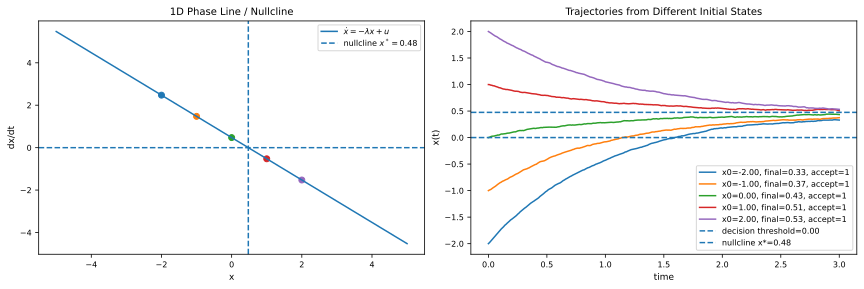

In [255]:
row = df_reaction.iloc[10]

result = run_single_trial_demo(
    row,
    beta_c=1.2,
    beta_i=0.8,
    beta_ci=0.5,
    gamma=1.0,
    kappa=1.0,
    lam=1.0,
    sigma=0.03,
    T=3.0,
    theta=0.0
)

In [256]:
df_sim = simulate_dataframe_decisions(df_reaction)
print(df_sim.head())

   idx   x0    u  nullcline_x   x_final  p_accept_pred  accept_pred  \
0    0  0.0  0.4          0.4  0.324870       0.580511            1   
1    1  0.0  0.4          0.4  0.322253       0.579873            1   
2    2  0.0  0.4          0.4  0.321582       0.579710            1   
3    3  0.0  0.4          0.4  0.424982       0.604675            1   
4    4  0.0  0.4          0.4  0.468432       0.615012            1   

   accept_true  
0            1  
1            1  
2            1  
3            1  
4            1  


In [258]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_sim["accept_true"], df_sim["accept_pred"])
print(cm)

[[  0 114]
 [  0 244]]


## 3.2 2d dynamics

In [321]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. Utilities
# =========================================================

def safe_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def normalize_mode(mode):
    if pd.isna(mode):
        return "manual"
    m = str(mode).strip().lower()
    if m in ["auto", "autonomous"]:
        return "auto"
    return "manual"

def normalize_time_pressure(v):
    if isinstance(v, (bool, np.bool_)):
        return int(v)
    if pd.isna(v):
        return 0
    if isinstance(v, str):
        s = v.strip().lower()
        return int(s in ["1", "true", "yes", "y"])
    return int(bool(v))


# =========================================================
# 2. Effective driving pressure
# =========================================================
# mean_throttle_input_zscore_pre2s is the base driving pressure
# auto mode reduces the effective pressure

def compute_effective_pressure(
    throttle_pressure,
    car_density,
    time_pressure,
    mode,
    auto_pressure_reduction=0.6,
    density_pressure_gain=0.8,
    time_pressure_gain=0.8,
):
    """
    Returns an effective pressure scalar used mainly for reject drive.

    throttle_pressure: mean_throttle_input_zscore_pre2s
    car_density: 0~1
    time_pressure: bool-like
    mode: auto/manual
    """
    mode_norm = normalize_mode(mode)
    tp = normalize_time_pressure(time_pressure)

    p_eff = float(throttle_pressure)

    # auto reduces burden
    if mode_norm == "auto":
        p_eff -= auto_pressure_reduction

    # dense traffic increases burden
    p_eff += density_pressure_gain * float(car_density)

    # time pressure increases burden
    p_eff += time_pressure_gain * tp

    return p_eff


# =========================================================
# 3. Construct accept / reject drives
# =========================================================

def compute_accept_reject_drives(
    prior_accept_prob,
    coherence,
    intensity,
    throttle_pressure,
    car_density,
    time_pressure,
    mode,

    # effective pressure parameters
    auto_pressure_reduction=0.6,
    density_pressure_gain=0.8,
    time_pressure_gain=0.8,

    # accept drive parameters
    b_x=0.0,
    alpha_prior=1.2,
    alpha_coherence=1.2,
    alpha_intensity=0.7,
    alpha_ci=0.4,
    alpha_density=0.3,

    # reject drive parameters
    b_y=0.0,
    beta_pressure=1.0,
    beta_density=0.8,
    beta_time_pressure=0.8,
    beta_low_coherence=1.0,
    beta_prior=1.0,
):
    """
    x-channel: accept drive
    y-channel: reject / resistance drive
    """
    lp = safe_logit(prior_accept_prob)
    C = float(coherence)
    I = float(intensity)
    D = float(car_density)
    TP = normalize_time_pressure(time_pressure)

    p_eff = compute_effective_pressure(
        throttle_pressure=throttle_pressure,
        car_density=car_density,
        time_pressure=time_pressure,
        mode=mode,
        auto_pressure_reduction=auto_pressure_reduction,
        density_pressure_gain=density_pressure_gain,
        time_pressure_gain=time_pressure_gain,
    )

    # Accept drive:
    # prior high -> more accept
    # coherence high -> more accept
    # intensity may help if recommendation is salient
    # density may mildly suppress acceptance
    f_x = (
        b_x
        + alpha_prior * lp
        + alpha_coherence * C
        + alpha_intensity * I
        + alpha_ci * C * I
        - alpha_density * D
    )

    # Reject drive:
    # effective pressure high -> more reject
    # high density -> more reject
    # time pressure -> more reject
    # low coherence -> more reject
    # high prior reduces reject
    f_y = (
        b_y
        + beta_pressure * p_eff
        + beta_density * D
        + beta_time_pressure * TP
        + beta_low_coherence * (1.0 - C)
        - beta_prior * lp
    )

    f_y = 0.4 * f_y

    return {
        "f_x": f_x,
        "f_y": f_y,
        "p_eff": p_eff,
        "prior_logit": lp
    }


# =========================================================
# 4. 2D dynamical system
# =========================================================
# dx/dt = -lam_x * x + f_x - w_xy * y + noise_x
# dy/dt = -lam_y * y + f_y - w_yx * x + noise_y

def simulate_2d_decision_system(
    x0,
    y0,
    f_x,
    f_y,
    lam_x=1.0,
    lam_y=1.0,
    w_xy=1.3,
    w_yx=1.3,
    sigma_x=0.02,
    sigma_y=0.02,
    dt=0.01,
    T=3.0,
    decision_threshold=0.0,
    random_state=None,
):
    rng = np.random.default_rng(random_state)

    n_steps = int(T / dt) + 1
    t = np.linspace(0, T, n_steps)

    x = np.zeros(n_steps)
    y = np.zeros(n_steps)
    x[0] = x0
    y[0] = y0

    for k in range(n_steps - 1):
        noise_x = sigma_x * np.sqrt(dt) * rng.normal()
        noise_y = sigma_y * np.sqrt(dt) * rng.normal()

        dx = (-lam_x * x[k] + f_x - w_xy * y[k]) * dt + noise_x
        dy = (-lam_y * y[k] + f_y - w_yx * x[k]) * dt + noise_y

        x[k + 1] = x[k] + dx
        y[k + 1] = y[k] + dy

    diff = x - y
    diff_final = diff[-1]
    p_accept = sigmoid(diff_final - decision_threshold)
    accept_pred = int(diff_final > decision_threshold)

    return {
        "t": t,
        "x": x,
        "y": y,
        "diff": diff,
        "x_final": x[-1],
        "y_final": y[-1],
        "diff_final": diff_final,
        "p_accept": p_accept,
        "accept_pred": accept_pred,
    }


# =========================================================
# 5. Nullclines and fixed point
# =========================================================

def x_nullcline(y, f_x, lam_x=1.0, w_xy=1.3):
    # dx/dt = 0 => x = (f_x - w_xy * y) / lam_x
    return (f_x - w_xy * y) / lam_x

def y_nullcline(x, f_y, lam_y=1.0, w_yx=1.3):
    # dy/dt = 0 => y = (f_y - w_yx * x) / lam_y
    return (f_y - w_yx * x) / lam_y

def fixed_point_2d(f_x, f_y, lam_x=1.0, lam_y=1.0, w_xy=1.3, w_yx=1.3):
    A = np.array([
        [lam_x, w_xy],
        [w_yx, lam_y]
    ], dtype=float)
    b = np.array([f_x, f_y], dtype=float)
    sol = np.linalg.solve(A, b)
    return sol[0], sol[1]


# =========================================================
# 6. Plot phase plane
# =========================================================

def plot_phase_plane(
    f_x,
    f_y,
    lam_x=1.0,
    lam_y=1.0,
    w_xy=1.3,
    w_yx=1.3,
    xlim=(-4, 4),
    ylim=(-4, 4),
    grid_n=21,
    ax=None,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    xs = np.linspace(xlim[0], xlim[1], grid_n)
    ys = np.linspace(ylim[0], ylim[1], grid_n)
    X, Y = np.meshgrid(xs, ys)

    U = -lam_x * X + f_x - w_xy * Y
    V = -lam_y * Y + f_y - w_yx * X

    ax.quiver(X, Y, U, V, angles="xy")

    # nullclines
    y_grid = np.linspace(ylim[0], ylim[1], 400)
    x_nc = x_nullcline(y_grid, f_x=f_x, lam_x=lam_x, w_xy=w_xy)
    ax.plot(x_nc, y_grid, label="dx/dt = 0")

    x_grid = np.linspace(xlim[0], xlim[1], 400)
    y_nc = y_nullcline(x_grid, f_y=f_y, lam_y=lam_y, w_yx=w_yx)
    ax.plot(x_grid, y_nc, label="dy/dt = 0")

    # decision boundary
    diag = np.linspace(max(xlim[0], ylim[0]), min(xlim[1], ylim[1]), 400)
    ax.plot(diag, diag, linestyle="--", label="x = y decision boundary")

    try:
        xf, yf = fixed_point_2d(
            f_x=f_x, f_y=f_y,
            lam_x=lam_x, lam_y=lam_y,
            w_xy=w_xy, w_yx=w_yx
        )
        ax.scatter([xf], [yf], s=60, label=f"fixed point ({xf:.2f}, {yf:.2f})")
    except np.linalg.LinAlgError:
        pass

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("accept state x")
    ax.set_ylabel("reject state y")
    ax.set_title("2D Decision Dynamics Phase Plane")
    ax.legend(fontsize=8)
    return ax


# =========================================================
# 7. Plot trajectories from multiple initial conditions
# =========================================================

def plot_trajectories_from_inits(
    init_points,
    f_x,
    f_y,
    lam_x=1.0,
    lam_y=1.0,
    w_xy=1.3,
    w_yx=1.3,
    sigma_x=0.02,
    sigma_y=0.02,
    dt=0.01,
    T=3.0,
    decision_threshold=0.0,
    xlim=(-4, 4),
    ylim=(-4, 4),
):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    plot_phase_plane(
        f_x=f_x,
        f_y=f_y,
        lam_x=lam_x,
        lam_y=lam_y,
        w_xy=w_xy,
        w_yx=w_yx,
        xlim=xlim,
        ylim=ylim,
        ax=axes[0],
    )

    for i, (x0, y0) in enumerate(init_points):
        res = simulate_2d_decision_system(
            x0=x0,
            y0=y0,
            f_x=f_x,
            f_y=f_y,
            lam_x=lam_x,
            lam_y=lam_y,
            w_xy=w_xy,
            w_yx=w_yx,
            sigma_x=sigma_x,
            sigma_y=sigma_y,
            dt=dt,
            T=T,
            decision_threshold=decision_threshold,
            random_state=100 + i,
        )
        axes[0].plot(res["x"], res["y"])
        axes[0].scatter([x0], [y0], s=25)
        axes[0].scatter([res["x_final"]], [res["y_final"]], s=40)

    for i, (x0, y0) in enumerate(init_points):
        res = simulate_2d_decision_system(
            x0=x0,
            y0=y0,
            f_x=f_x,
            f_y=f_y,
            lam_x=lam_x,
            lam_y=lam_y,
            w_xy=w_xy,
            w_yx=w_yx,
            sigma_x=sigma_x,
            sigma_y=sigma_y,
            dt=dt,
            T=T,
            decision_threshold=decision_threshold,
            random_state=100 + i,
        )
        label = f"({x0:.1f},{y0:.1f}) -> pred={res['accept_pred']}"
        axes[1].plot(res["t"], res["diff"], label=label)

    axes[1].axhline(decision_threshold, linestyle="--", label="decision threshold")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("x(t) - y(t)")
    axes[1].set_title("Decision Variable Difference")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# =========================================================
# 8. Default initial condition
# =========================================================
# Use prior to set an initial bias:
#   x0 = +k_init * logit(prior)
#   y0 = -k_init * logit(prior)

def default_initial_condition(prior_accept_prob, k_init=1.0):
    lp = safe_logit(prior_accept_prob)
    return k_init * lp, -k_init * lp


# =========================================================
# 9. Single-trial demo
# =========================================================

def run_single_trial_demo_2d(row,
                             # effective pressure params
                             auto_pressure_reduction=0.6,
                             density_pressure_gain=0.8,
                             time_pressure_gain=0.8,

                             # accept drive params
                             b_x=0.0,
                             alpha_prior=1.2,
                             alpha_coherence=1.2,
                             alpha_intensity=0.7,
                             alpha_ci=0.4,
                             alpha_density=0.3,

                             # reject drive params
                             b_y=0.0,
                             beta_pressure=1.0,
                             beta_density=0.8,
                             beta_time_pressure=0.8,
                             beta_low_coherence=1.0,
                             beta_prior=1.0,

                             # dynamics params
                             k_init=1.0,
                             lam_x=1.0,
                             lam_y=1.0,
                             w_xy=1.3,
                             w_yx=1.3,
                             sigma_x=0.02,
                             sigma_y=0.02,
                             dt=0.01,
                             T=3.0,
                             decision_threshold=0.0):
    p0 = float(row["subject_prior_accept_prob_subcategory"])
    coherence = float(row["coherence"])
    intensity = float(row["intensity"])
    throttle_pressure = float(row["mean_throttle_pre2s"])
    car_density = float(row["car_density"])
    time_pressure = row["time_pressure"]
    mode = row["mode"]

    drives = compute_accept_reject_drives(
        prior_accept_prob=p0,
        coherence=coherence,
        intensity=intensity,
        throttle_pressure=throttle_pressure,
        car_density=car_density,
        time_pressure=time_pressure,
        mode=mode,

        auto_pressure_reduction=auto_pressure_reduction,
        density_pressure_gain=density_pressure_gain,
        time_pressure_gain=time_pressure_gain,

        b_x=b_x,
        alpha_prior=alpha_prior,
        alpha_coherence=alpha_coherence,
        alpha_intensity=alpha_intensity,
        alpha_ci=alpha_ci,
        alpha_density=alpha_density,

        b_y=b_y,
        beta_pressure=beta_pressure,
        beta_density=beta_density,
        beta_time_pressure=beta_time_pressure,
        beta_low_coherence=beta_low_coherence,
        beta_prior=beta_prior,
    )

    f_x = drives["f_x"]
    f_y = drives["f_y"]
    p_eff = drives["p_eff"]

    x0, y0 = default_initial_condition(p0, k_init=k_init)

    res = simulate_2d_decision_system(
        x0=x0,
        y0=y0,
        f_x=f_x,
        f_y=f_y,
        lam_x=lam_x,
        lam_y=lam_y,
        w_xy=w_xy,
        w_yx=w_yx,
        sigma_x=sigma_x,
        sigma_y=sigma_y,
        dt=dt,
        T=T,
        decision_threshold=decision_threshold,
        random_state=42,
    )

    xf, yf = fixed_point_2d(
        f_x=f_x,
        f_y=f_y,
        lam_x=lam_x,
        lam_y=lam_y,
        w_xy=w_xy,
        w_yx=w_yx
    )

    print("===== Single Trial Demo (2D) =====")
    print(f"prior_accept_prob = {p0:.3f}")
    print(f"coherence = {coherence:.3f}")
    print(f"intensity = {intensity:.3f}")
    print(f"throttle_pressure = {throttle_pressure:.3f}")
    print(f"car_density = {car_density:.3f}")
    print(f"time_pressure = {normalize_time_pressure(time_pressure)}")
    print(f"mode = {normalize_mode(mode)}")
    print(f"effective_pressure = {p_eff:.3f}")
    print(f"accept drive f_x = {f_x:.3f}")
    print(f"reject drive f_y = {f_y:.3f}")
    print(f"initial state = ({x0:.3f}, {y0:.3f})")
    print(f"fixed point = ({xf:.3f}, {yf:.3f})")
    print(f"final state = ({res['x_final']:.3f}, {res['y_final']:.3f})")
    print(f"final diff x-y = {res['diff_final']:.3f}")
    print(f"p_accept = {res['p_accept']:.3f}")
    print(f"accept_pred = {res['accept_pred']}")

    init_points = [
        (x0, y0),
        (x0 - 1.0, y0),
        (x0 + 1.0, y0),
        (x0, y0 - 1.0),
        (x0, y0 + 1.0),
        (x0 - 1.0, y0 - 1.0),
        (x0 + 1.0, y0 + 1.0),
    ]

    plot_trajectories_from_inits(
        init_points=init_points,
        f_x=f_x,
        f_y=f_y,
        lam_x=lam_x,
        lam_y=lam_y,
        w_xy=w_xy,
        w_yx=w_yx,
        sigma_x=sigma_x,
        sigma_y=sigma_y,
        dt=dt,
        T=T,
        decision_threshold=decision_threshold,
    )

    return {
        "drives": drives,
        "simulation": res,
        "fixed_point": (xf, yf)
    }


# =========================================================
# 10. Batch simulation for dataframe
# =========================================================

def simulate_dataframe_2d(
    df,
    # effective pressure params
    auto_pressure_reduction=0.6,
    density_pressure_gain=0.8,
    time_pressure_gain=0.8,

    # accept drive params
    b_x=0.0,
    alpha_prior=1.2,
    alpha_coherence=1.2,
    alpha_intensity=0.7,
    alpha_ci=0.4,
    alpha_density=0.3,

    # reject drive params
    b_y=0.0,
    beta_pressure=1.0,
    beta_density=0.8,
    beta_time_pressure=0.8,
    beta_low_coherence=1.0,
    beta_prior=1.0,

    # dynamics
    k_init=1.0,
    lam_x=1.0,
    lam_y=1.0,
    w_xy=1.3,
    w_yx=1.3,
    sigma_x=0.02,
    sigma_y=0.02,
    dt=0.01,
    T=3.0,
    decision_threshold=0.0,
):
    records = []

    for idx, row in df.iterrows():
        p0 = float(row["subject_prior_accept_prob_subcategory"])
        coherence = float(row["coherence"])
        intensity = float(row["intensity"])
        throttle_pressure = float(row["mean_throttle_pre2s"])
        car_density = float(row["car_density"])
        time_pressure = row["time_pressure"]
        mode = row["mode"]

        drives = compute_accept_reject_drives(
            prior_accept_prob=p0,
            coherence=coherence,
            intensity=intensity,
            throttle_pressure=throttle_pressure,
            car_density=car_density,
            time_pressure=time_pressure,
            mode=mode,

            auto_pressure_reduction=auto_pressure_reduction,
            density_pressure_gain=density_pressure_gain,
            time_pressure_gain=time_pressure_gain,

            b_x=b_x,
            alpha_prior=alpha_prior,
            alpha_coherence=alpha_coherence,
            alpha_intensity=alpha_intensity,
            alpha_ci=alpha_ci,
            alpha_density=alpha_density,

            b_y=b_y,
            beta_pressure=beta_pressure,
            beta_density=beta_density,
            beta_time_pressure=beta_time_pressure,
            beta_low_coherence=beta_low_coherence,
            beta_prior=beta_prior,
        )

        x0, y0 = default_initial_condition(p0, k_init=k_init)

        res = simulate_2d_decision_system(
            x0=x0,
            y0=y0,
            f_x=drives["f_x"],
            f_y=drives["f_y"],
            lam_x=lam_x,
            lam_y=lam_y,
            w_xy=w_xy,
            w_yx=w_yx,
            sigma_x=sigma_x,
            sigma_y=sigma_y,
            dt=dt,
            T=T,
            decision_threshold=decision_threshold,
            random_state=idx,
        )

        try:
            xf, yf = fixed_point_2d(
                f_x=drives["f_x"],
                f_y=drives["f_y"],
                lam_x=lam_x,
                lam_y=lam_y,
                w_xy=w_xy,
                w_yx=w_yx
            )
        except np.linalg.LinAlgError:
            xf, yf = np.nan, np.nan

        rec = {
            "idx": idx,
            "prior_accept_prob": p0,
            "prior_logit": drives["prior_logit"],
            "coherence": coherence,
            "intensity": intensity,
            "throttle_pressure": throttle_pressure,
            "car_density": car_density,
            "time_pressure": normalize_time_pressure(time_pressure),
            "mode": normalize_mode(mode),
            "effective_pressure": drives["p_eff"],
            "f_x": drives["f_x"],
            "f_y": drives["f_y"],
            "x0": x0,
            "y0": y0,
            "fixed_x": xf,
            "fixed_y": yf,
            "x_final": res["x_final"],
            "y_final": res["y_final"],
            "diff_final": res["diff_final"],
            "p_accept_pred": res["p_accept"],
            "accept_pred": res["accept_pred"],
        }

        if "accept" in row.index:
            rec["accept_true"] = int(row["accept"])

        records.append(rec)

    return pd.DataFrame(records)

===== Single Trial Demo (2D) =====
prior_accept_prob = 0.500
coherence = 0.000
intensity = 0.500
throttle_pressure = 0.000
car_density = 0.800
time_pressure = 1
mode = manual
effective_pressure = 1.400
accept drive f_x = -0.010
reject drive f_y = 1.624
initial state = (0.000, -0.000)
fixed point = (9.764, -6.516)
final state = (-9.260, 8.089)
final diff x-y = -17.350
p_accept = 0.000
accept_pred = 0


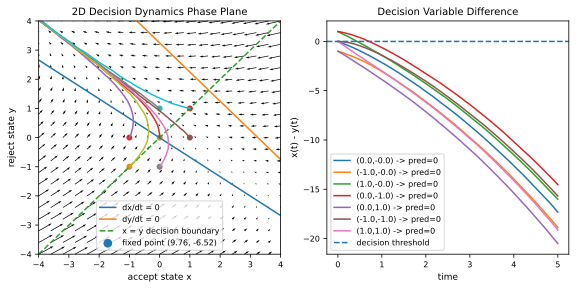

In [ ]:
row = df_reaction.iloc[0]

demo = run_single_trial_demo_2d(
    row,
    auto_pressure_reduction=1.0,
    density_pressure_gain=0.5,
    time_pressure_gain=1.0,

    alpha_prior=1.5,
    alpha_coherence=1.5,
    alpha_intensity=0.3,
    alpha_ci=0.4,
    alpha_density=0.2,

    beta_pressure=1.1,
    beta_density=0.9,
    beta_time_pressure=0.8,
    beta_low_coherence=1.0,
    beta_prior=1.0,

    lam_x=1.0,
    lam_y=1.0,
    w_xy=1.5,
    w_yx=1.5,
    sigma_x=0.02,
    sigma_y=0.02,
    T=5.0
)

In [337]:
df_reaction = df_reaction[df_reaction["recommendation_category"] == 2]

df_sim = simulate_dataframe_2d(df_reaction,
    auto_pressure_reduction=1.0,
    density_pressure_gain=0.5,
    time_pressure_gain=1.0,

    alpha_prior=1.5,
    alpha_coherence=1.5,
    alpha_intensity=0.3,
    alpha_ci=0.4,
    alpha_density=0.2,

    beta_pressure=1.1,
    beta_density=0.9,
    beta_time_pressure=0.8,
    beta_low_coherence=1.0,
    beta_prior=1.0,

    lam_x=1.0,
    lam_y=1.0,
    w_xy=1.0,
    w_yx=0.5,
    sigma_x=0.02,
    sigma_y=0.02,
    T=10.0,
)
# print(df_sim.head())

valid = df_sim.dropna(subset=["accept_true"])
acc = (valid["accept_pred"] == valid["accept_true"]).mean()
print("original acceptance rate =", valid["accept_true"].mean())
print("accuracy =", acc)

original acceptance rate = 0.5754189944134078
accuracy = 0.46368715083798884
